## Import Libraries

Load the Python libraries needed for data handling, numerical operations, visualization, and local file paths.

In [332]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler


## Load Census Data

Read the column names from `census-bureau.columns`, then use them as headers when loading `census-bureau.data` into `raw_data`.

In [ ]:
columns_path = Path("../src/data/census-bureau.columns")
with open(columns_path, "r") as f:
    columns = [line.strip() for line in f if line.strip()]

data_path = Path("../src/data/census-bureau.data")

raw_data = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    skipinitialspace=True
)

## Basic Data Cleaning

Remove duplicate rows and fill the missing values in `hispanic origin` with `?`, matching the dataset's existing unknown-value convention.

In [334]:
# replace space in column names with underscore for easier usage
raw_data.columns =(raw_data.columns.str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False))

columns = [
    col.strip()
       .lower()
       .replace(" ", "_")
       .replace("-", "_")
    for col in columns
]

# remove duplicates
raw_data = raw_data.drop_duplicates(keep="first")

# change missing value to "?" in Hispanic Origin column
raw_data.loc[:, "hispanic_origin"] = raw_data.loc[:, "hispanic_origin"].fillna("?")

## Encode Binary Columns

Convert the income label into a binary target and map `sex` from text labels into numeric values for modeling.

In [335]:
# map the values in the label column from '50000+.' to 1 and 0 otherwise.
raw_data['label'] = raw_data["label"].map(
    lambda x: 1 if str(x).strip() == '50000+.' else 0)

# map the values in the sex column from Male/Female to 1/0
raw_data["sex"] = raw_data["sex"].map(
    lambda x: 1 if str(x).strip() == "Male" else 0)

# map the values in the year column from Male/Female to 1/0
raw_data["year"] = raw_data["year"].map(
    lambda x: 1 if str(x).strip() == '94' else 0)

## Separate Sampling Weight

Store the Census sampling `weight` column in its own datafram.e

In [336]:
# Keep the Census sampling weight separately, then remove it from the feature dataframe.
weight = raw_data[['weight']].copy()
raw_data = raw_data.drop(columns=['weight'])
columns.remove("weight")

print(f'raw_data shape after dropping weight: {raw_data.shape}')
print(f'weight shape: {weight.shape}')

raw_data shape after dropping weight: (196294, 41)
weight shape: (196294, 1)


## Feature Engineering: Age

Convert the continuous `age` column into ordered age buckets. This can make age easier for models to use when the relationship between age and income is not strictly linear.

In [337]:
def add_age_bucket(df, age_col='age', new_col='age_bucket'):
    """Convert age into ordered categorical age buckets."""
    df = df.copy() 
    
    bins = [-1, 17, 24, 34, 44, 54, 64, np.inf]
    labels = ["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

    df.loc[:, new_col] = pd.cut(
        df[age_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    return df

In [338]:
df = raw_data[['age']]
df = add_age_bucket(df)

age_bucket_dummies = pd.get_dummies(
    df['age_bucket'],
    prefix='age_bucket',
    dtype=int
)

age_bucket_dummies.columns = age_bucket_dummies.columns.str.replace('+', 'plus', regex=False)
age_bucket_dummies.columns = age_bucket_dummies.columns.str.replace('-', '_', regex=False)

columns.extend(list(age_bucket_dummies.columns))
raw_data = pd.concat([raw_data, age_bucket_dummies], axis=1)

## Feature Engineering: Money and Investment Features
Create two new features for each money-related column "wage per hour", "capital gains", "capital losses", and "dividends from stocks": a binary indicator showing whether the person has any value in that column, and a log-transformed version to reduce the effect of large outliers.

In [339]:
def add_money_features(df, columns):
    """Create indicator and log-transformed features for money-related columns."""
    df = df.copy()

    money_cols = [
        "wage_per_hour",
        "capital_gains",
        "capital_losses",
        "dividends_from_stocks"
    ]

    for col in money_cols:
        if col in df.columns:
            df[f"has_{col}"] = (df[col] > 0).astype(int)
            df[f"log_{col}"] = np.log1p(df[col])
            columns.append(f"has_{col}")
            columns.append(f"log_{col}")

    return df


raw_data = add_money_features(raw_data, columns=columns)


## Feature Engineering: Weeks Worked in Year
Create employment-intensity features from `weeks worked in year`: whether the person worked at all, whether they worked all 52 weeks, and a bucketed version of weeks worked.

In [340]:
def add_weeks_worked_features(df, weeks_col='weeks_worked_in_year', new_col='weeks_worked_bucket'):
    """Create binary and bucketed features from weeks worked in year."""
    df = df.copy()

    df['worked_none_year'] = (df[weeks_col] == 0).astype(int)
    df['worked_full_year'] = (df[weeks_col] == 52).astype(int)

    df.loc[:, new_col] = pd.cut(
        df[weeks_col],
        bins=[0, 13, 26, 39, 51],
        labels=[
            '1-13 weeks',
            '14-26 weeks',
            '27-39 weeks',
            '40-51 weeks',
        ]
    )

    return df

df = raw_data[['weeks_worked_in_year']]
df = add_weeks_worked_features(df)

weeks_worked_bucket_dummies = pd.get_dummies(
    df['weeks_worked_bucket'],
    prefix='weeks_worked',
    dtype=int
)

weeks_worked_bucket_dummies.columns = (
    weeks_worked_bucket_dummies.columns
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

df = pd.concat([df, weeks_worked_bucket_dummies], axis=1).drop(columns=['weeks_worked_in_year', 'weeks_worked_bucket'])

columns.extend(list(df.columns))
raw_data = pd.concat([raw_data, df], axis=1)

## Feature Engineering: Industry and Occupation

Convert `detailed_industry_recode` and `detailed_occupation_recode` to strings so they are treated as categorical identifiers rather than continuous numeric values. Then one-hot encode `major_industry_code` and `major_occupation_code` to create model-ready indicator features for broad industry and occupation groups.

In [341]:
def add_industry_occupation_features(df):
    """Convert detailed recodes to strings and one-hot encode major industry/occupation."""
    df = df.copy()

    detailed_cols = [
        'detailed_industry_recode',
        'detailed_occupation_recode'
    ]

    for col in detailed_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)

    major_cols = [
        'major_industry_code',
        'major_occupation_code'
    ]

    major_dummies = pd.get_dummies(
        df[major_cols],
        prefix=major_cols,
        dtype=int
    )

    major_dummies.columns = (
        major_dummies.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace('-', '_', regex=False)
        .str.replace('&', 'and', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace("'", '', regex=False)
        .str.replace(',', '', regex=False)
    )

    df = pd.concat([df, major_dummies], axis=1)

    return df, list(major_dummies.columns)


raw_data, industry_occupation_dummy_cols = add_industry_occupation_features(raw_data)
columns.extend(industry_occupation_dummy_cols)

## Feature Engineering: Group Similar Categorical Levels

Group selected categorical columns into broader categories before one-hot encoding. This reduces sparse dummy variables, combines rare levels, and keeps related categories together when the original feature has many small groups.

In [342]:
def group_class_of_worker(val):
    """Group class of worker into broader employment categories."""
    val = str(val).strip()
    if val == "Not in universe":
        return "not_applicable"
    elif val == "Private":
        return "private"
    elif "Self-employed" in val:
        return "self_employed"
    elif "government" in val.lower():
        return "government"
    elif val in ["Never worked", "Without pay"]:
        return "other_non_working"
    else:
        return "other"


def group_marital_status(val):
    """Group marital status into broader relationship categories."""
    val = str(val).strip()

    if 'Married' in val:
        return 'married'
    elif val == 'Never married':
        return 'never_married'
    elif val == 'Divorced':
        return 'no_spouse_divorced'
    else:
        return 'no_spouse_other'


def group_race(val):
    """Keep White as its own group and combine smaller race groups."""
    val = str(val).strip()

    if val == 'White':
        return 'white'
    if val == 'Black':
        return 'black'
    if val == 'Asian or Pacific Islander':
        return 'asian'
    else:
        return 'other'


def group_hispanic_origin(val):
    """Group Hispanic origin into Hispanic, non-Hispanic, and unknown."""
    val = str(val).strip()

    if val == '?':
        return 'unknown'
    elif val == 'All other':
        return 'not_hispanic'
    else:
        return 'hispanic'


def group_country_of_birth(val):
    """Group country of birth into broad geographic regions."""
    val = str(val).strip()

    north_america = [
        'United-States', 'Canada', 'Mexico',
        'Outlying-U S (Guam USVI etc)'
    ]

    latin_america = [
        'Puerto-Rico', 'Cuba', 'Jamaica', 'Dominican-Republic',
        'Haiti', 'El-Salvador', 'Guatemala', 'Honduras',
        'Nicaragua', 'Ecuador', 'Peru', 'Columbia',
        'Trinadad&Tobago', 'Panama'
    ]

    europe = [
        'England', 'Germany', 'Greece', 'Holand-Netherlands',
        'Hungary', 'Ireland', 'Italy', 'Poland', 'Portugal',
        'Scotland', 'Yugoslavia', 'France'
    ]

    asia = [
        'China', 'India', 'Iran', 'Japan', 'Cambodia',
        'Laos', 'Philippines', 'Taiwan', 'Thailand',
        'Vietnam', 'Hong Kong', 'South Korea'
    ]

    if val in ['?', 'Not in universe']:
        return 'unknown'
    elif val in north_america:
        return 'north_america'
    elif val in latin_america:
        return 'latin_america'
    elif val in europe:
        return 'europe'
    elif val in asia:
        return 'asia'
    else:
        return 'other'


def group_full_or_part_time_employment(val):
    """Group full/part-time employment status into broader categories."""
    val = str(val).strip()

    unemployed_full_time = [
        'Unemployed full-time'
    ]

    part_time_or_unemployed_part_time = [
        'PT for econ reasons usually FT',
        'PT for econ reasons usually PT',
        'PT for non-econ reasons usually FT',
        'Unemployed part- time'
    ]

    if val == 'Not in labor force':
        return 'not_in_labor_force'
    elif val == 'Children or Armed Forces':
        return 'children_or_AF'
    elif val in unemployed_full_time:
        return 'unemployed_full_time'
    elif val in part_time_or_unemployed_part_time:
        return 'part_time_or_unemployed_part_time'
    elif val == 'Full-time schedules':
        return 'full_time'
    else:
        return 'other'
    

def group_education(val):
    """Group education levels into broader education bands."""
    val = str(val).strip()

    if val == 'Children':
        return 'children'
    elif val in [
        'Less than 1st grade',
        '1st 2nd 3rd or 4th grade',
        '5th or 6th grade',
        '7th and 8th grade',
        '9th grade',
        '10th grade',
        '11th grade',
        '12th grade no diploma'
    ]:
        return 'less_than_high_school'
    elif val == 'High school graduate':
        return 'high_school'
    elif val in [
        'Some college but no degree',
        'Associates degree-occup /vocational',
        'Associates degree-academic program'
    ]:
        return 'some_college_or_associate'
    elif val == 'Bachelors degree(BA AB BS)':
        return 'bachelors'
    elif val in [
        'Masters degree(MA MS MEng MEd MSW MBA)',
        'Prof school degree (MD DDS DVM LLB JD)',
        'Doctorate degree(PhD EdD)'
    ]:
        return 'graduate_degree'
    else:
        return 'other'


def group_family_members_under_18(val):
    """Group family members under 18 into simpler child-presence categories."""
    val = str(val).strip()

    if val == 'Not in universe':
        return 'not_in_universe'
    elif val == 'Neither parent present':
        return 'no_parent_present'
    elif val in ['Mother only present', 'Father only present']:
        return 'one_parent_present'
    elif val == 'Both parents present':
        return 'both_parents_present'
    else:
        return 'other'

def group_detailed_household_summary(val):
    """Group detailed household/family status into four broader categories."""
    val = str(val).strip().lower()

    if 'spouse' in val:
        return 'spouse_of_householder'
    elif val == 'householder':
        return 'householder'
    elif 'child' in val:
        return 'child'
    else:
        return 'other'

def group_citizenship(val):
    """Group citizenship into broader citizenship-status categories."""
    val = str(val).strip()
    if val == "Native- Born in the United States":
        return "native_us_born"
    elif val == "Foreign born- U S citizen by naturalization":
        return "naturalized_citizen"
    elif val == "Foreign born- Not a citizen of U S":
        return "non_citizen"
    elif val == "Native- Born abroad of American Parent(s)":
        return "native_born_abroad"
    elif val == "Native- Born in Puerto Rico or U S Outlying":
        return "native_us_territory"


def group_migration_region(val):
    """Group migration region change into broader migration categories."""
    val = str(val).strip()
    if val == "?":
        return "unknown"
    elif val == "Nonmover":
        return "nonmover"
    elif val in [
        "Same county",
        "Different county same state"
    ]:
        return "local_mover"
    elif val in [
        "Different state same division",
        "Different division same region",
        "Different region"
    ]:
        return "long_distance_domestic_mover"
    elif val == "Abroad":
        return "international_mover"
    elif val == "Not in universe":
        return "not_applicable"
    else:
        return "other"


def add_grouped_categorical_features(df):
    """Create grouped versions of selected categorical columns."""
    df = df.copy()

    grouping_map = {
        'class_of_worker': group_class_of_worker,
        'marital_stat': group_marital_status,
        'race': group_race,
        'hispanic_origin': group_hispanic_origin,
        'education': group_education,
        'family_members_under_18': group_family_members_under_18,
        'country_of_birth_self': group_country_of_birth,
        'full_or_part_time_employment_stat': group_full_or_part_time_employment,
        'detailed_household_summary_in_household': group_detailed_household_summary,
        'citizenship': group_citizenship,
        'migration_code_change_in_reg': group_migration_region
    }

    grouped_cols = []

    for col, group_func in grouping_map.items():
        if col in df.columns:
            new_col = f'{col}_grouped'
            df[new_col] = df[col].apply(group_func)
            grouped_cols.append(new_col)

    return df, grouped_cols


raw_data, grouped_categorical_cols = add_grouped_categorical_features(raw_data)

columns.extend(grouped_categorical_cols)

## Feature Engineering: Other Categorical Features
One-hot encode remaining categorical columns such as `own_business_or_self_employed` and `veterans_benefits`. These columns use small numeric codes, but the values represent categories rather than continuous measurements, so dummy variables are more appropriate for modeling.

In [343]:
def clean_dummy_column_names(dummy_df):
    """Standardize dummy column names after one-hot encoding."""
    dummy_df = dummy_df.copy()
    dummy_df.columns = (
        dummy_df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace('-', '_', regex=False)
        .str.replace('&', 'and', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace("'", '', regex=False)
        .str.replace(',', '', regex=False)
    )
    return dummy_df


def one_hot_encode_features(df, feature_cols, drop_original=True):
    """One-hot encode selected categorical features and optionally drop the original columns."""
    df = df.copy()
    existing_cols = [col for col in feature_cols if col in df.columns]

    if not existing_cols:
        return df, []

    dummy_df = pd.get_dummies(
        df[existing_cols].astype(str),
        prefix=existing_cols,
        dtype=int
    )
    dummy_df = clean_dummy_column_names(dummy_df)

    df = pd.concat([df, dummy_df], axis=1)

    if drop_original:
        df = df.drop(columns=existing_cols)

    return df, list(dummy_df.columns)


other_categorical_cols = grouped_categorical_cols + [
    'own_business_or_self_employed',
    'veterans_benefits',
    'member_of_a_labor_union',
    'live_in_this_house_1_year_ago',
    'tax_filer_stat',
]

raw_data, other_categorical_dummy_cols = one_hot_encode_features(
    raw_data,
    other_categorical_cols,
    drop_original=True
)

columns = [col for col in columns if col not in other_categorical_cols]
columns.extend(other_categorical_dummy_cols)

In [344]:
for col, total in raw_data[columns[36:]].sum().items():
    print(col, total)

age_bucket_0_17 52826.0
age_bucket_18_24 17806.0
age_bucket_25_34 30880.0
age_bucket_35_44 31413.0
age_bucket_45_54 23195.0
age_bucket_55_64 15906.0
age_bucket_65plus 24268.0
has_wage_per_hour 11303.0
log_wage_per_hour 76211.0697645516
has_capital_gains 7379.0
log_capital_gains 63969.86674673548
has_capital_losses 3906.0
log_capital_losses 29368.167534372536
has_dividends_from_stocks 21138.0
log_dividends_from_stocks 120683.55971608491
worked_none_year 92770.0
worked_full_year 70308.0
weeks_worked_1_13_weeks 7609.0
weeks_worked_14_26_weeks 7597.0
weeks_worked_27_39_weeks 6247.0
weeks_worked_40_51_weeks 11763.0
major_industry_code_agriculture 3021.0
major_industry_code_armed_forces 36.0
major_industry_code_business_and_repair_services 5651.0
major_industry_code_communications 1181.0
major_industry_code_construction 5984.0
major_industry_code_education 8283.0
major_industry_code_entertainment 1650.0
major_industry_code_finance_insurance_and_real_estate 6145.0
major_industry_code_forestry

## Feature Engineering: Scale Numerical Columns

Scale continuous numerical features before fitting logistic regression. Logistic regression is sensitive to feature scale because it uses coefficient-based optimization, so standardizing numeric columns helps the model train more reliably and makes coefficients easier to compare.

In [345]:
numeric_cols_to_scale = [
    'wage_per_hour',
    'capital_gains',
    'capital_losses',
    'dividends_from_stocks',
    'num_persons_worked_for_employer',
    'weeks_worked_in_year',
    'log_wage_per_hour',
    'log_capital_gains',
    'log_capital_losses',
    'log_dividends_from_stocks'
]

numeric_cols_to_scale = [
    col for col in numeric_cols_to_scale
    if col in raw_data.columns
]

scaler = StandardScaler()

scaled_numeric_data = pd.DataFrame(
    scaler.fit_transform(raw_data[numeric_cols_to_scale]),
    columns=[f'scaled_{col}' for col in numeric_cols_to_scale],
    index=raw_data.index
)

raw_data = pd.concat([raw_data, scaled_numeric_data], axis=1)
columns.extend(scaled_numeric_data.columns.tolist())

## Feature Selection
Create the final modeling feature set (total of 122 features) for logistic regression. The feature engineering notebook creates the following groups of new model features:

### Age Features
- One-hot encoded age bucket columns:
  - `age_bucket_0_17`
  - `age_bucket_18_24`
  - `age_bucket_25_34`
  - `age_bucket_35_44`
  - `age_bucket_45_54`
  - `age_bucket_55_64`
  - `age_bucket_65plus`

### Money and Investment Features
For each money-related column, a binary indicator and log-transformed feature are created.
- `has_wage_per_hour`
- `log_wage_per_hour`
- `has_capital_gains`
- `log_capital_gains`
- `has_capital_losses`
- `log_capital_losses`
- `has_dividends_from_stocks`
- `log_dividends_from_stocks`
*Note: we will use the scaled version of the log_transformed features*

### Weeks Worked Features
From `weeks_worked_in_year`, the notebook creates:
- `worked_none_year`
- `worked_full_year`
- `weeks_worked_1_13_weeks`
- `weeks_worked_14_26_weeks`
- `weeks_worked_27_39_weeks`
- `weeks_worked_40_51_weeks`

### Industry and Occupation Features
The major industry and occupation columns are one-hot encoded (examples):
- `major_industry_code_agriculture`
- `major_industry_code_construction`
- `major_industry_code_retail_trade`
- `major_occupation_code_executive_admin_and_managerial`
- `major_occupation_code_professional_specialty`
- `major_occupation_code_sales`
*Note: here we will drop major_industry_code_not_in_universe_or_children and major_industry_code_armed_forces columns as they are the same with their major_occupation counterparts*

### Grouped Categorical Features
Several categorical columns are grouped into broader categories before one-hot encoding.
- `class_of_worker_grouped_*`
- `marital_stat_grouped_*`
- `race_grouped_*`
- `hispanic_origin_grouped_*`
- `education_grouped_*`
- `family_members_under_18_grouped_*`
- `country_of_birth_self_grouped_*`
- `full_or_part_time_employment_stat_grouped_*`
- `detailed_household_summary_in_household_grouped_*`
- `citizenship_grouped_*`
- `migration_code_change_in_reg_grouped_*`

### Other One-Hot Encoded Categorical Features
Additional categorical columns are one-hot encoded directly:
- `own_business_or_self_employed_*`
- `veterans_benefits_*`
- `member_of_a_labor_union_*`
- `live_in_this_house_1_year_ago_*`
- `tax_filer_stat_*`

### Scaled Numerical Features
The following numerical columns are standardized for logistic regression:
- `scaled_wage_per_hour`
- `scaled_capital_gains`
- `scaled_capital_losses`
- `scaled_dividends_from_stocks`
- `scaled_num_persons_worked_for_employer`
- `scaled_weeks_worked_in_year`
- `scaled_log_wage_per_hour`
- `scaled_log_capital_gains`
- `scaled_log_capital_losses`
- `scaled_log_dividends_from_stocks`

### Binary indicators
- `sex`
- `year`
- `label`

### Features Excluded from Final Model
The following features were excluded from model training due to extreme class imbalance (mostly `"Unknown"` / `"Not in universe"`), high sparsity, redundancy with stronger features, or limited predictive value:
- `detailed_industry_recode` — overly granular; redundant with `major_industry_code`
- `detailed_occupation_recode` — overly granular; redundant with `major_occupation_code`
- `enroll_in_edu_inst_last_wk` — over 95%  `"Not in universe"`
- `reason_for_unemployment` — over 95% `"Not in universe"`
- `region_of_previous_residence` — highly sparse and migration-related redundancy
- `state_of_previous_residence` — over 95% `"Not in universe"`
- `detailed_household_and_family_stat` — overly granular; overlaps with marital/household features
- `migration_code_change_in_msa` — redundant with broader migration features
- `migration_code_move_within_reg` — redundant migration signal
- `migration_prev_res_in_sunbelt` — mostly `"Unknown"` / weak predictive signal
- `country_of_birth_father` — high-cardinality and weak signal
- `country_of_birth_mother` — high-cardinality and weak signal
- `fill_inc_questionnaire_for_veteran's_admin` — overwhelmingly `"Not in universe"`

### Sensitive Features Excluded from Final Model
To reduce fairness and compliance risk, the following sensitive or sensitive-adjacent demographic features were excluded from model training:

- `race` — direct sensitive demographic attribute
- `sex` — direct sensitive demographic attribute
- `hispanic_origin` — ethnicity-related sensitive attribute
- `country_of_birth_self` — potential proxy for nationality/ethnicity

These features may contain predictive signal, but using them directly in an income prediction model could introduce fairness and compliance concerns, especially in a financial-services context. Therefore, they were excluded from the final feature set and retained only for exploratory analysis or post-model fairness checks.


In [346]:
# feature selection

label_idx = columns.index('label')

selected_features = columns[label_idx + 1:].copy()

cols_to_drop = [
    "major_industry_code_not_in_universe_or_children",
    "major_industry_code_armed_forces",
    "log_wage_per_hour",
    "log_capital_gains",
    "log_capital_losses",
    "log_dividends_from_stocks",
]

sensitive_prefixes = [
    'race',
    'hispanic_origin',
    'country_of_birth_self',
    'sex'
]

sensitive_features = [
    col for col in columns
    if col.startswith(tuple(sensitive_prefixes))
]

cols_to_add = ["year"]

selected_features = [
    col for col in selected_features
    if col not in cols_to_drop + sensitive_features
] + cols_to_add

selected_features = [
    col for col in selected_features
    if col in raw_data.columns
]

X = raw_data[selected_features].copy()
y = raw_data['label'].copy()

print(f'Number of selected features: {len(selected_features)}')

X.head()

Number of selected features: 122


,age_bucket_0_17,age_bucket_18_24,age_bucket_25_34,age_bucket_35_44,age_bucket_45_54,age_bucket_55_64,age_bucket_65plus,has_wage_per_hour,has_capital_gains,has_capital_losses,...,scaled_capital_gains,scaled_capital_losses,scaled_dividends_from_stocks,scaled_num_persons_worked_for_employer,scaled_weeks_worked_in_year,scaled_log_wage_per_hour,scaled_log_capital_gains,scaled_log_capital_losses,scaled_log_dividends_from_stocks,year
0,0,0,0,0,0,0,1,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.838505,-0.964196,-0.246421,-0.196124,-0.142379,-0.323792,0
1,0,0,0,0,0,1,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.416744,1.164463,-0.246421,-0.196124,-0.142379,-0.323792,1
2,0,1,0,0,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.838505,-0.964196,-0.246421,-0.196124,-0.142379,-0.323792,0
3,1,0,0,0,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.838505,-0.964196,-0.246421,-0.196124,-0.142379,-0.323792,1
4,1,0,0,0,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.838505,-0.964196,-0.246421,-0.196124,-0.142379,-0.323792,1


## Modeling: Train, Validation, and Test Split With Sample Weights

Split the engineered data into train, validation, and test sets. The Census `weight` column is not used as a model feature, but it is split alongside `X` and `y` so it can be used as `sample_weight` during model training and weighted evaluation.

In [361]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

X_train_full, X_test, y_train_full, y_test, weight_train_full, weight_test = train_test_split(
    X,
    y,
    weight,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val, weight_train, weight_val = train_test_split(
    X_train_full,
    y_train_full,
    weight_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

weight_train = weight_train.values.ravel()
weight_val = weight_val.values.ravel()
weight_test = weight_test.values.ravel()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (125628, 122)
Validation: (31407, 122)
Test: (39259, 122)


## Logistic Regression With Imbalance-Aware Weights

Train and tune a logistic regression model using both Census survey weights and class-balance weights. The survey weights account for the population represented by each row, while class-balance weights help address the income-label imbalance.

In [377]:
from sklearn.utils.class_weight import compute_sample_weight

class_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

final_train_weight_lr = weight_train * class_weight_train

## XGBoost Modeling With Imbalance-Aware Weights

Train and tune an XGBoost model using both Census survey weights and class-imbalance weights. The Census weight accounts for the population represented by each record, while the class-imbalance weight helps the model pay more attention to the minority income class.

In [367]:
from sklearn.utils.class_weight import compute_sample_weight

class_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

final_train_weight = weight_train * class_weight_train

## Baseline Weighted XGBoost Model

Fit a baseline XGBoost classifier before hyperparameter tuning. This gives a reference point for ranking quality using ROC-AUC and PR-AUC.

In [368]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(
    X_train,
    y_train,
    sample_weight=final_train_weight,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[weight_val],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=-1, num_parallel_tree=None, ...)

## Evaluate Baseline Ranking Quality

Evaluate the baseline model using ROC-AUC and PR-AUC. For this imbalanced classification problem, PR-AUC is especially important because it focuses more directly on positive-class performance.

In [369]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_proba = xgb_baseline.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(
    y_val,
    val_proba,
    sample_weight=weight_val
)

pr_auc = average_precision_score(
    y_val,
    val_proba,
    sample_weight=weight_val
)

print("Validation ROC-AUC:", roc_auc)
print("Validation PR-AUC:", pr_auc)


Validation ROC-AUC: 0.9488462859518054
Validation PR-AUC: 0.6501194269564089


## Tune XGBoost With Optuna

Use Optuna to tune XGBoost hyperparameters against validation PR-AUC. PR-AUC is used as the optimization target because the positive class is relatively rare.

In [371]:
%pip install optuna
import optuna
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

def objective(trial):
    params = {
        "n_estimators": 800,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train,
        y_train,
        sample_weight=final_train_weight,
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[weight_val],
        verbose=False
    )

    val_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        val_proba,
        sample_weight=weight_val
    )

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best validation PR-AUC:", study.best_value)
print("Best params:")
print(study.best_params)

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


[I 2026-05-22 07:28:34,687] A new study created in memory with name: no-name-ea9445a6-56a0-4dca-857a-00eb458f42d4
[I 2026-05-22 07:29:13,107] Trial 0 finished with value: 0.6436918299551204 and parameters: {'learning_rate': 0.026580554680002547, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.8544973347528964, 'colsample_bytree': 0.7420620944409823, 'reg_lambda': 0.9215690762353798, 'reg_alpha': 2.8559802567529364}. Best is trial 0 with value: 0.6436918299551204.
[I 2026-05-22 07:30:04,348] Trial 1 finished with value: 0.6421521758947897 and parameters: {'learning_rate': 0.026134609961078227, 'max_depth': 7, 'min_child_weight': 19, 'subsample': 0.7727998096022839, 'colsample_bytree': 0.921630281923907, 'reg_lambda': 0.6937599100615351, 'reg_alpha': 3.2254750138716655}. Best is trial 0 with value: 0.6436918299551204.
[I 2026-05-22 07:30:58,030] Trial 2 finished with value: 0.6490583309502044 and parameters: {'learning_rate': 0.013959133489252809, 'max_depth': 7, 'min_child_weight'

Best validation PR-AUC: 0.6531741709582558
Best params:
{'learning_rate': 0.030755537152993076, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.8876297872934952, 'colsample_bytree': 0.8472481041189223, 'reg_lambda': 1.6330317368215317, 'reg_alpha': 2.9770443163981124}


## Train Final Tuned XGBoost Model

Train the final XGBoost model using the best hyperparameters found by Optuna.

In [372]:
best_params = study.best_params

final_xgb = XGBClassifier(
    n_estimators=800,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

final_xgb.fit(
    X_train,
    y_train,
    sample_weight=final_train_weight,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[weight_val],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8472481041189223, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.030755537152993076,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, ...)

## Tune Classification Threshold

Tune the probability threshold on the validation set using positive-class F1 score. This is better than using the default `0.5` threshold for an imbalanced dataset.

In [373]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

val_proba = final_xgb.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.05, 0.95, 0.01):
    y_val_pred = (val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        sample_weight=weight_val,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        sample_weight=weight_val,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        sample_weight=weight_val,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]

best_row

threshold    0.810000
precision    0.543726
recall       0.675889
f1           0.602647
Name: 76, dtype: float64

## Optional Business Threshold: Top 10 Percent Targeting

For a marketing-style use case, evaluate performance when targeting only the top 10% of records by predicted probability.

In [374]:
top_k_pct = 0.10

cutoff = np.quantile(val_proba, 1 - top_k_pct)

y_val_pred_topk = (val_proba >= cutoff).astype(int)

precision_topk = precision_score(
    y_val,
    y_val_pred_topk,
    sample_weight=weight_val,
    zero_division=0
)

recall_topk = recall_score(
    y_val,
    y_val_pred_topk,
    sample_weight=weight_val,
    zero_division=0
)

print("Top 10% probability cutoff:", cutoff)
print("Precision@Top10%:", precision_topk)
print("Recall@Top10%:", recall_topk)

Top 10% probability cutoff: 0.74236958026886
Precision@Top10%: 0.46549245571686093
Recall@Top10%: 0.7410016332564813


## Final Test Evaluation

Evaluate the final tuned XGBoost model once on the test set using the threshold selected from the validation set.

In [375]:
from sklearn.metrics import classification_report, confusion_matrix

test_proba = final_xgb.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba,
    sample_weight=weight_test
)

test_pr_auc = average_precision_score(
    y_test,
    test_proba,
    sample_weight=weight_test
)

test_precision = precision_score(
    y_test,
    test_pred,
    sample_weight=weight_test,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    sample_weight=weight_test,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    sample_weight=weight_test,
    zero_division=0
)

print("Best threshold:", best_threshold)
print("Test ROC-AUC:", test_roc_auc)
print("Test PR-AUC:", test_pr_auc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)

print(classification_report(
    y_test,
    test_pred,
    sample_weight=weight_test,
    target_names=["<= 50000", "> 50000"],
    zero_division=0
))

cm = confusion_matrix(
    y_test,
    test_pred,
    sample_weight=weight_test
)

cm

Best threshold: 0.8100000000000002
Test ROC-AUC: 0.9481437126741996
Test PR-AUC: 0.6546459614495663
Test Precision: 0.52799807002545
Test Recall: 0.6704567422810502
Test F1: 0.5907604731106222
              precision    recall  f1-score   support

    <= 50000       0.98      0.96      0.97 63772258.90999975
     > 50000       0.53      0.67      0.59 4501017.500000011

    accuracy                           0.94 68273276.40999976
   macro avg       0.75      0.81      0.78 68273276.40999976
weighted avg       0.95      0.94      0.94 68273276.40999976



array([[61074563.55999986,  2697695.35      ],
       [ 1483279.97      ,  3017737.53      ]])

## Save Model Artifacts

Save the final tuned model and modeling metadata so the results can be reused later.

In [ ]:
import joblib
import json

joblib.dump(final_xgb, "../src/model_registry/final_xgb_model_wt_sensitive.joblib")

model_metadata = {
    "best_params": study.best_params,
    "best_validation_pr_auc": study.best_value,
    "best_threshold": float(best_threshold),
    "test_roc_auc": float(test_roc_auc),
    "test_pr_auc": float(test_pr_auc),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1)
}

with open("../src/model_registry/model_metadata_wt_sensitive.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

## Model Interpretation: SHAP for XGBoost

Use SHAP values to interpret the tuned XGBoost model. SHAP explains how each feature contributes to the model's predicted probability ranking. Because SHAP can be slow on large datasets, use a sample from the validation set.

In [379]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Prepare Feature Names for SHAP

Because the current feature matrix is already a pandas dataframe, use `X_train.columns` directly as the feature names.

In [380]:
feature_names = X_train.columns.tolist()

feature_names[:20]

['age_bucket_0_17',
 'age_bucket_18_24',
 'age_bucket_25_34',
 'age_bucket_35_44',
 'age_bucket_45_54',
 'age_bucket_55_64',
 'age_bucket_65plus',
 'has_wage_per_hour',
 'has_capital_gains',
 'has_capital_losses',
 'has_dividends_from_stocks',
 'worked_none_year',
 'worked_full_year',
 'weeks_worked_1_13_weeks',
 'weeks_worked_14_26_weeks',
 'weeks_worked_27_39_weeks',
 'weeks_worked_40_51_weeks',
 'major_industry_code_agriculture',
 'major_industry_code_business_and_repair_services',
 'major_industry_code_communications']

## Sample Validation Data for SHAP

Sample up to 5,000 rows from the validation set to make SHAP computation faster.

In [381]:
sample_size = 5000

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    X_val.shape[0],
    size=min(sample_size, X_val.shape[0]),
    replace=False
)

X_shap = X_val.iloc[sample_idx]

X_shap_df = pd.DataFrame(
    X_shap,
    columns=feature_names
)

X_shap_df.head()

,age_bucket_0_17,age_bucket_18_24,age_bucket_25_34,age_bucket_35_44,age_bucket_45_54,age_bucket_55_64,age_bucket_65plus,has_wage_per_hour,has_capital_gains,has_capital_losses,...,scaled_capital_gains,scaled_capital_losses,scaled_dividends_from_stocks,scaled_num_persons_worked_for_employer,scaled_weeks_worked_in_year,scaled_log_wage_per_hour,scaled_log_capital_gains,scaled_log_capital_losses,scaled_log_dividends_from_stocks,year
160539,0,0,1,0,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.838505,-0.964196,-0.246421,-0.196124,-0.142379,-0.323792,1
134675,1,0,0,0,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,0.848539,-0.636710,-0.246421,-0.196124,-0.142379,-0.323792,0
60152,0,1,0,0,0,0,0,1,0,0,...,-0.093307,-0.138381,-0.100355,1.692061,-0.472967,3.759616,-0.196124,-0.142379,-0.323792,1
148301,0,0,0,0,1,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,0.848539,1.164463,-0.246421,-0.196124,-0.142379,-0.323792,0
178252,0,0,0,1,0,0,0,0,0,0,...,-0.093307,-0.138381,-0.100355,-0.416744,0.100133,-0.246421,-0.196124,-0.142379,-0.323792,0


## Create SHAP Explainer

Use `TreeExplainer` for the final tuned XGBoost model.

In [382]:
explainer = shap.TreeExplainer(final_xgb)

shap_values = explainer.shap_values(X_shap_df)

## SHAP Summary Dot Plot

The SHAP dot plot shows the most influential features and whether high or low feature values push predictions higher or lower.

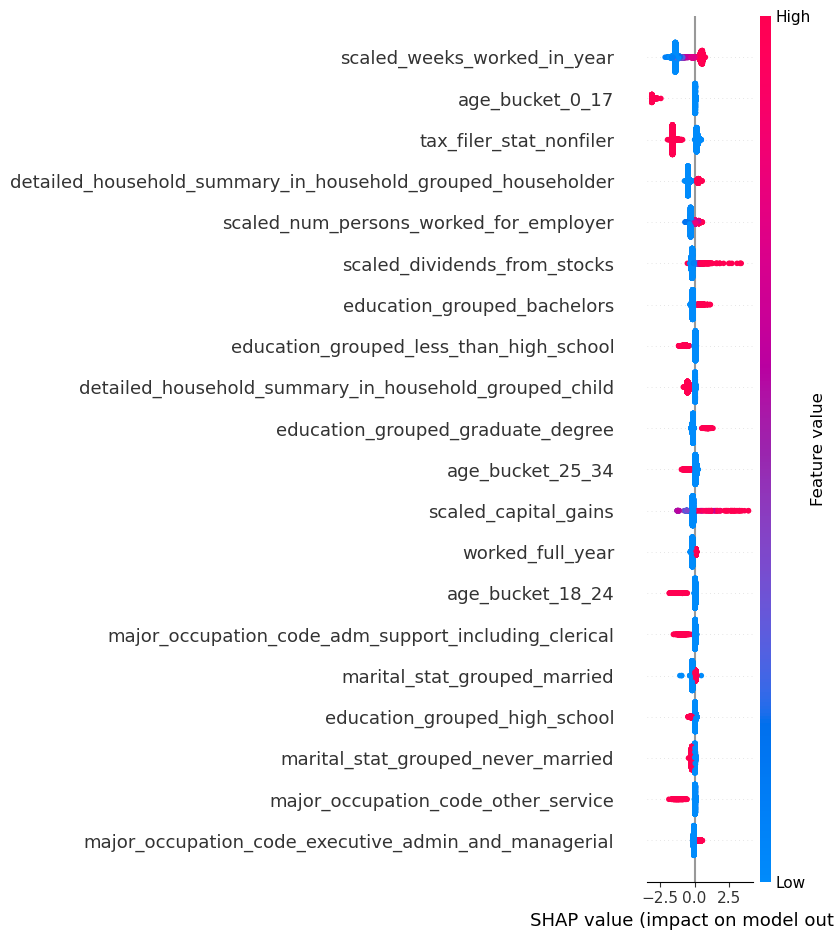

In [383]:
shap.summary_plot(
    shap_values,
    X_shap_df,
    max_display=20,
    show=True
)

## SHAP Bar Plot

The SHAP bar plot ranks features by their average absolute SHAP value.

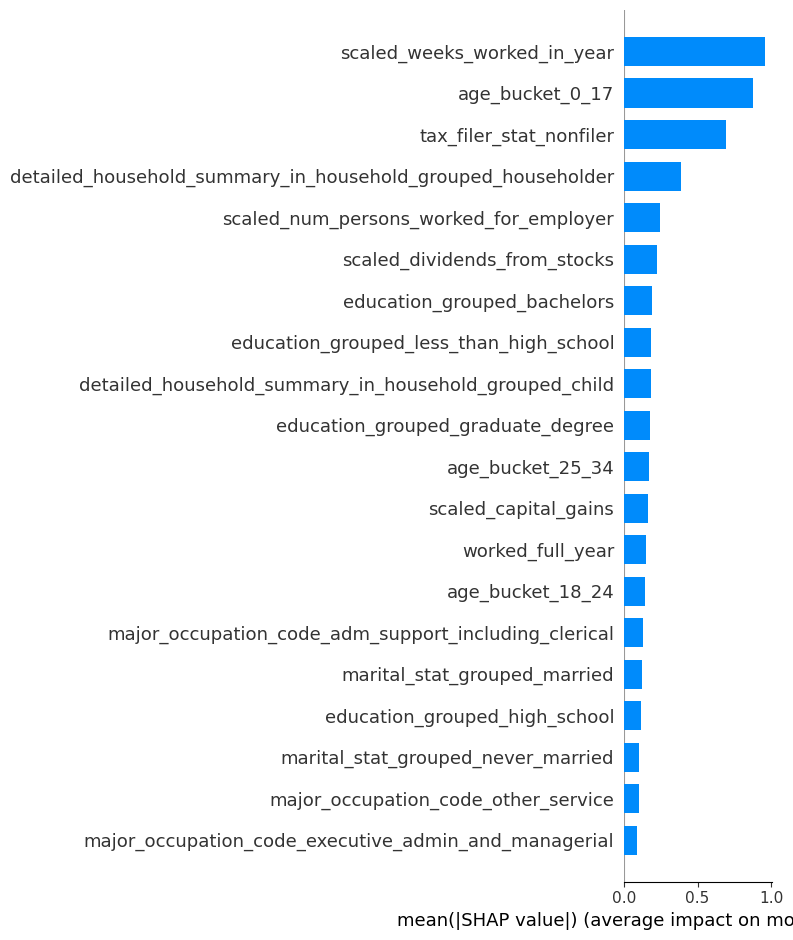

In [384]:
shap.summary_plot(
    shap_values,
    X_shap_df,
    plot_type="bar",
    max_display=20,
    show=True
)

## Group One-Hot SHAP Importances

One-hot encoding can spread importance across many dummy columns. Group related dummy features back to their original feature families for a more readable interpretation.

In [385]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(20)

,feature,mean_abs_shap
116,scaled_weeks_worked_in_year,0.959052
0,age_bucket_0_17,0.875595
109,tax_filer_stat_nonfiler,0.693471
79,detailed_household_summary_in_household_groupe...,0.388910
115,scaled_num_persons_worked_for_employer,0.247688
114,scaled_dividends_from_stocks,0.221323
63,education_grouped_bachelors,0.191051
67,education_grouped_less_than_high_school,0.182799
78,detailed_household_summary_in_household_groupe...,0.182239
65,education_grouped_graduate_degree,0.177649


In [386]:
def clean_feature_group(feature_name):
    """Group one-hot encoded feature names back to original feature families."""
    known_prefixes = [
        "age_bucket",
        "weeks_worked",
        "major_industry_code",
        "major_occupation_code",
        "class_of_worker_grouped",
        "marital_stat_grouped",
        "race_grouped",
        "hispanic_origin_grouped",
        "education_grouped",
        "family_members_under_18_grouped",
        "country_of_birth_self_grouped",
        "full_or_part_time_employment_stat_grouped",
        "detailed_household_summary_in_household_grouped",
        "citizenship_grouped",
        "migration_code_change_in_reg_grouped",
        "own_business_or_self_employed",
        "veterans_benefits",
        "member_of_a_labor_union",
        "live_in_this_house_1_year_ago",
        "tax_filer_stat",
        "year"
    ]

    for prefix in known_prefixes:
        if feature_name.startswith(prefix):
            return prefix

    return feature_name


shap_importance["feature_group"] = shap_importance["feature"].apply(clean_feature_group)

grouped_shap_importance = (
    shap_importance
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_shap_importance.head(20)

,feature_group,mean_abs_shap
0,age_bucket,1.345004
1,scaled_weeks_worked_in_year,0.959052
2,tax_filer_stat,0.763844
3,education_grouped,0.695141
4,major_occupation_code,0.617346
5,detailed_household_summary_in_household_grouped,0.612268
6,major_industry_code,0.356040
7,scaled_num_persons_worked_for_employer,0.247688
8,marital_stat_grouped,0.246570
9,scaled_dividends_from_stocks,0.221323


## Plot Grouped SHAP Importances

Plot the top feature groups by total mean absolute SHAP value.

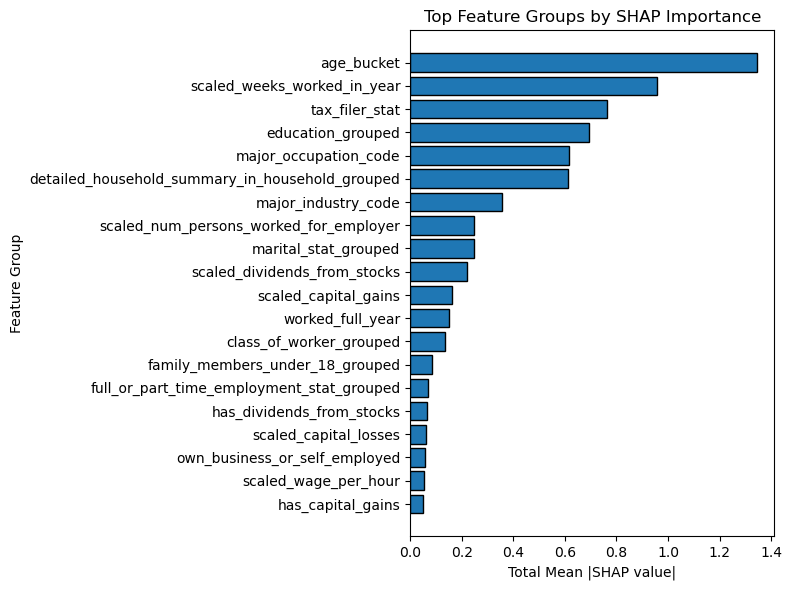

In [387]:
top_grouped = grouped_shap_importance.head(20).sort_values("mean_abs_shap")

plt.figure(figsize=(8, 6))
plt.barh(
    top_grouped["feature_group"],
    top_grouped["mean_abs_shap"],
    edgecolor="black"
)

plt.title("Top Feature Groups by SHAP Importance")
plt.xlabel("Total Mean |SHAP value|")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()

## Segmentation: Sample Data for Clustering Visualization

Use the final modeling feature matrix `X` as the segmentation input. Because the dataset has nearly 200K rows, sample a subset for visualization and expensive clustering methods.

In [388]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_seg = X
df_seg = raw_data.copy()

sample_size = 20000

sample_idx = np.random.RandomState(42).choice(
    X_seg.shape[0],
    size=min(sample_size, X_seg.shape[0]),
    replace=False
)

X_seg_sample = X_seg.iloc[sample_idx]
df_seg_sample = df_seg.iloc[sample_idx].copy()

## Segmentation: Create 2D Projection With TruncatedSVD

Use `TruncatedSVD` instead of PCA because the feature matrix contains many one-hot encoded columns and may be sparse or high-dimensional.

In [389]:
from sklearn.decomposition import TruncatedSVD

svd_2d = TruncatedSVD(n_components=2, random_state=42)

X_plot_2d = svd_2d.fit_transform(X_seg_sample)

plot_df = pd.DataFrame({
    "component_1": X_plot_2d[:, 0],
    "component_2": X_plot_2d[:, 1]
})

print("Explained variance ratio:", svd_2d.explained_variance_ratio_)
print("Total explained variance:", svd_2d.explained_variance_ratio_.sum())

Explained variance ratio: [0.00610893 0.20510542]
Total explained variance: 0.21121435218198684


## Segmentation Method 1: K-means

Fit K-means clustering on the sampled segmentation data. K-means is a strong baseline segmentation method because it is simple, scalable, and easy to interpret.

In [404]:
from sklearn.cluster import KMeans

k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_labels_sample = kmeans.fit_predict(X_seg_sample)

plot_df["kmeans_segment"] = kmeans_labels_sample

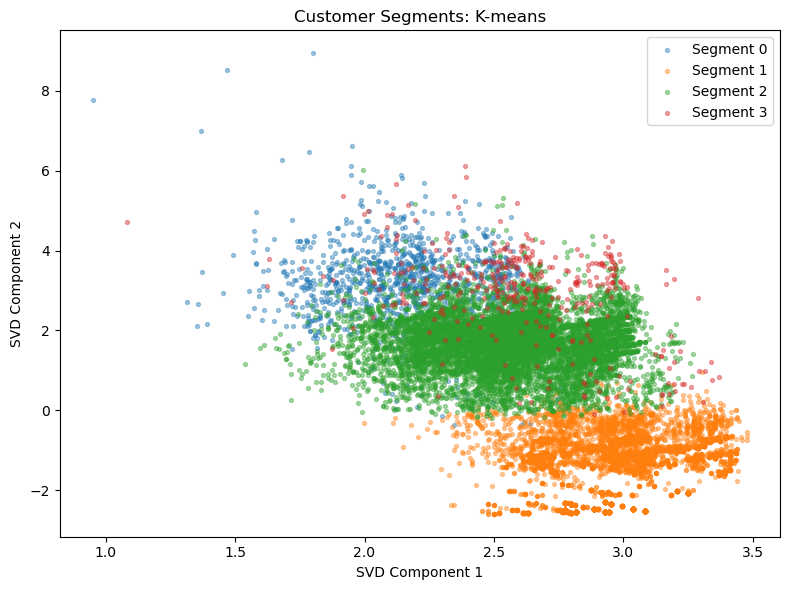

In [405]:
plt.figure(figsize=(8, 6))

for segment in sorted(plot_df["kmeans_segment"].unique()):
    subset = plot_df[plot_df["kmeans_segment"] == segment]
    plt.scatter(
        subset["component_1"],
        subset["component_2"],
        s=8,
        alpha=0.4,
        label=f"Segment {segment}"
    )

plt.title("Customer Segments: K-means")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Segmentation Method 2: Gaussian Mixture Model

Fit a Gaussian Mixture Model on lower-dimensional SVD features. GMM requires dense input, so the sampled data is reduced to 20 dimensions first.

In [406]:
from sklearn.mixture import GaussianMixture

svd_20 = TruncatedSVD(n_components=20, random_state=42)
X_seg_sample_20d = svd_20.fit_transform(X_seg_sample)

gmm = GaussianMixture(
    n_components=k,
    covariance_type="diag",
    random_state=42
)

gmm_labels_sample = gmm.fit_predict(X_seg_sample_20d)

plot_df["gmm_segment"] = gmm_labels_sample

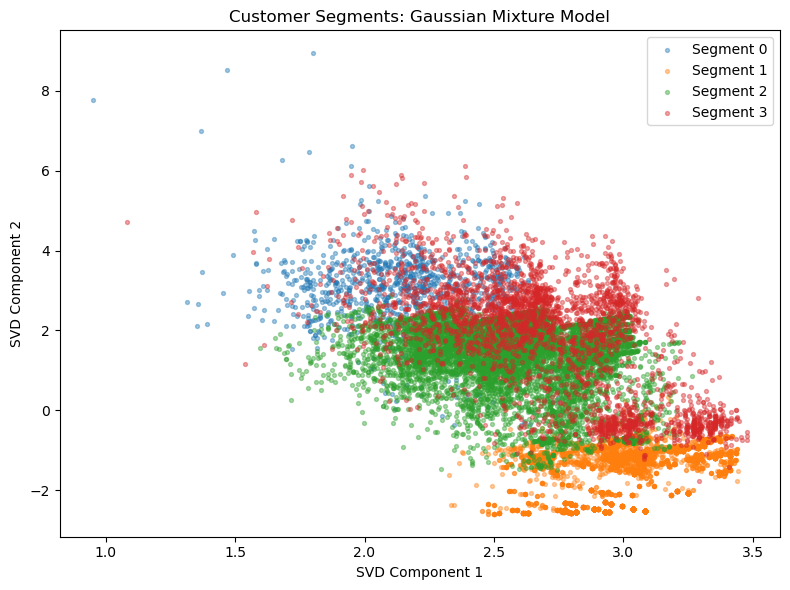

In [407]:
plt.figure(figsize=(8, 6))

for segment in sorted(plot_df["gmm_segment"].unique()):
    subset = plot_df[plot_df["gmm_segment"] == segment]
    plt.scatter(
        subset["component_1"],
        subset["component_2"],
        s=8,
        alpha=0.4,
        label=f"Segment {segment}"
    )

plt.title("Customer Segments: Gaussian Mixture Model")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Segmentation Method 3: BIRCH

Fit BIRCH clustering on the 20-dimensional SVD features. BIRCH is useful for larger datasets and can be more scalable than traditional hierarchical clustering.

In [408]:
from sklearn.cluster import Birch

birch = Birch(
    n_clusters=k,
    threshold=0.5
)

birch_labels_sample = birch.fit_predict(X_seg_sample_20d)

plot_df["birch_segment"] = birch_labels_sample

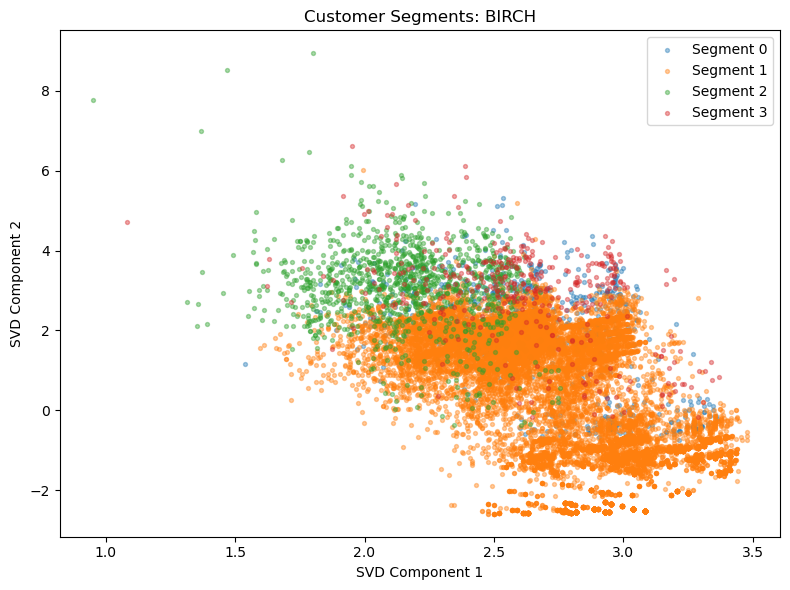

In [409]:
plt.figure(figsize=(8, 6))

for segment in sorted(plot_df["birch_segment"].unique()):
    subset = plot_df[plot_df["birch_segment"] == segment]
    plt.scatter(
        subset["component_1"],
        subset["component_2"],
        s=8,
        alpha=0.4,
        label=f"Segment {segment}"
    )

plt.title("Customer Segments: BIRCH")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Segmentation Method 4: Agglomerative Clustering

Fit agglomerative clustering on the 20-dimensional SVD sample. This method can be expensive, so it should be used only on the sampled data.

In [410]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

agg_labels_sample = agg.fit_predict(X_seg_sample_20d)

plot_df["agg_segment"] = agg_labels_sample

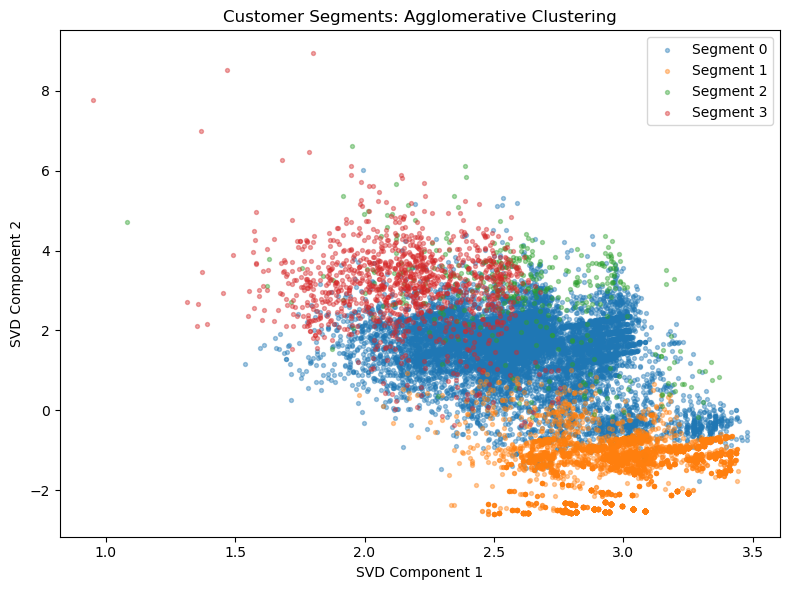

In [411]:
plt.figure(figsize=(8, 6))

for segment in sorted(plot_df["agg_segment"].unique()):
    subset = plot_df[plot_df["agg_segment"] == segment]
    plt.scatter(
        subset["component_1"],
        subset["component_2"],
        s=8,
        alpha=0.4,
        label=f"Segment {segment}"
    )

plt.title("Customer Segments: Agglomerative Clustering")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Compare Segmentation Methods

Compare clustering methods using silhouette score on the same 20-dimensional SVD representation.

In [412]:
from sklearn.metrics import silhouette_score

cluster_comparison = []

for method_name, labels in [
    ("K-means", kmeans_labels_sample),
    ("Gaussian Mixture", gmm_labels_sample),
    ("BIRCH", birch_labels_sample),
    ("Agglomerative", agg_labels_sample)
]:
    score = silhouette_score(X_seg_sample_20d, labels)

    cluster_comparison.append({
        "method": method_name,
        "silhouette_score": score,
        "num_clusters": len(np.unique(labels))
    })

cluster_comparison_df = pd.DataFrame(cluster_comparison)

cluster_comparison_df.sort_values("silhouette_score", ascending=False)

,method,silhouette_score,num_clusters
2,BIRCH,0.430213,4
0,K-means,0.314836,4
3,Agglomerative,0.298205,4
1,Gaussian Mixture,0.268725,4


## Fit Final K-means Segmentation Model

After comparing methods, fit K-means on the full segmentation feature matrix and assign each record to a segment.

In [413]:
final_k = 4

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

raw_data["segment"] = final_kmeans.fit_predict(X_seg)

## Plot Segment Sizes

Show the number of records assigned to each final segment.

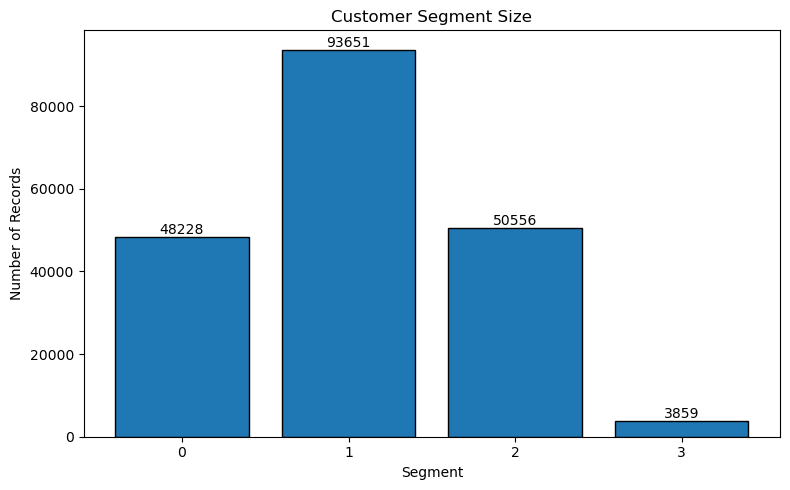

In [414]:
segment_counts = raw_data["segment"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index.astype(str), segment_counts.values, edgecolor="black")

plt.title("Customer Segment Size")
plt.xlabel("Segment")
plt.ylabel("Number of Records")

for i, value in enumerate(segment_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## High-Income Rate by Segment

Compare the high-income rate across segments using the `label` target.

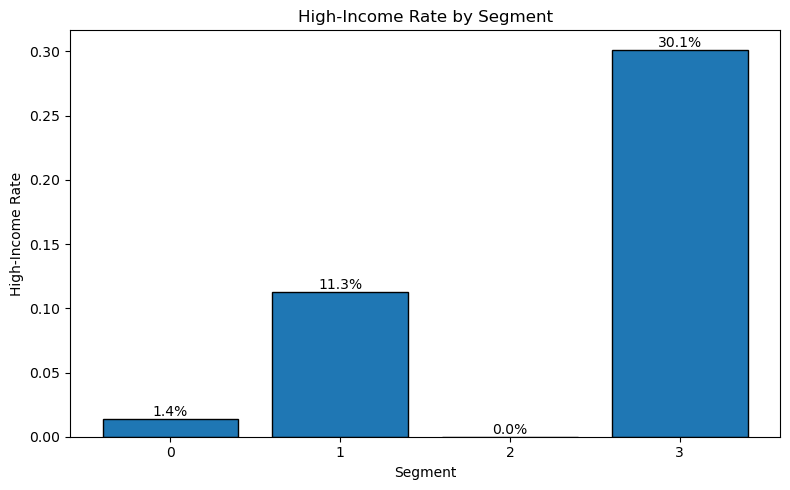

In [415]:
segment_income_rate = (
    raw_data.groupby("segment")["label"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(segment_income_rate.index.astype(str), segment_income_rate.values, edgecolor="black")

plt.title("High-Income Rate by Segment")
plt.xlabel("Segment")
plt.ylabel("High-Income Rate")

for i, value in enumerate(segment_income_rate.values):
    plt.text(i, value, f"{value:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Segment Numerical Profile

Create a summary table showing average numerical and engineered features for each segment.

In [416]:
profile_cols = [
    "age",
    "label",
    "has_wage_per_hour",
    "has_capital_gains",
    "has_capital_losses",
    "has_dividends_from_stocks",
    "log_wage_per_hour",
    "log_capital_gains",
    "log_capital_losses",
    "log_dividends_from_stocks",
    "weeks_worked_in_year",
    "worked_none_year",
    "worked_full_year"
]

available_profile_cols = [
    col for col in profile_cols
    if col in raw_data.columns
]

segment_profile = (
    raw_data.groupby("segment")[available_profile_cols]
    .mean()
    .round(3)
)

segment_profile

,age,label,has_wage_per_hour,has_capital_gains,has_capital_losses,has_dividends_from_stocks,log_wage_per_hour,log_capital_gains,log_capital_losses,log_dividends_from_stocks,weeks_worked_in_year,worked_none_year,worked_full_year
segment,,,,,,,,,,,,,
0,54.914,0.014,0.002,0.030,0.001,0.128,0.010,0.243,0.003,0.820,1.430,0.888,0.001
1,38.760,0.113,0.117,0.063,0.000,0.149,0.787,0.558,0.001,0.802,46.771,0.002,0.722
2,8.077,0.000,0.001,0.000,0.000,0.001,0.006,0.000,0.000,0.003,0.273,0.976,0.000
3,44.002,0.301,0.065,0.000,1.000,0.252,0.450,0.000,7.539,1.532,41.624,0.119,0.672


## Segment Categorical Profile

For each segment, show the most common category for selected original or grouped categorical features.

In [417]:
def top_category_by_segment(df, segment_col, feature_col):
    return (
        df.groupby(segment_col)[feature_col]
        .agg(lambda x: x.value_counts(dropna=False).index[0])
        .reset_index()
        .rename(columns={feature_col: f"top_{feature_col}"})
    )


categorical_profile_cols = [
    "education",
    "education_grouped",
    "weeks_worked_bucket",
    "class_of_worker",
    "class_of_worker_grouped",
    "major_industry_code",
    "major_occupation_code",
    "marital_stat",
    "marital_stat_grouped",
    "full_or_part_time_employment_stat",
    "full_or_part_time_employment_stat_grouped",
    "member_of_a_labor_union"
]

for col in categorical_profile_cols:
    if col in raw_data.columns:
        display(top_category_by_segment(raw_data, "segment", col))

,segment,top_education
0,0,High school graduate
1,1,High school graduate
2,2,Children
3,3,High school graduate


,segment,top_class_of_worker
0,0,Not in universe
1,1,Private
2,2,Not in universe
3,3,Private


,segment,top_major_industry_code
0,0,Not in universe or children
1,1,Retail trade
2,2,Not in universe or children
3,3,Not in universe or children


,segment,top_major_occupation_code
0,0,Not in universe
1,1,Adm support including clerical
2,2,Not in universe
3,3,Not in universe


,segment,top_marital_stat
0,0,Married-civilian spouse present
1,1,Married-civilian spouse present
2,2,Never married
3,3,Married-civilian spouse present


,segment,top_full_or_part_time_employment_stat
0,0,Children or Armed Forces
1,1,Children or Armed Forces
2,2,Children or Armed Forces
3,3,Children or Armed Forces
